In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline

1) Utilize Linear(first degree polynomial) and spline interpolation to see which method is the best fit for this data, i.e. does this justify linear regression. 

In [2]:
def merger(pathCal, pathMass):
    df1 = pd.read_csv(pathCal)
    df2 = pd.read_csv(pathMass)

    df1["Date"] = pd.to_datetime(df1["Date"])
    df2["Date"] = pd.to_datetime(df2["Date"])

    daily_calories = df1.groupby("Date", as_index=False)["Calories"].sum()
    daily_calories["Calories"] = np.ceil(daily_calories["Calories"]).astype(int)

    daily_weight = df2.groupby("Date", as_index=False)["Weight"].mean()

    all_dates = pd.DataFrame({
        "Date": pd.date_range(
            start=min(df1["Date"].min(), df2["Date"].min()),
            end=max(df1["Date"].max(), df2["Date"].max())
        )
    })

    merged_df = all_dates \
        .merge(daily_calories, on="Date", how="left") \
        .merge(daily_weight, on="Date", how="left")

    merged_df["day"] = (merged_df["Date"] - merged_df["Date"].min()).dt.days

    return merged_df

calories_data = "Calories.csv"
weight_data = "Weight.csv"
merger(calories_data,weight_data).to_csv("output.csv", index = False)



── Weight Interpolation ──
  Linear → MAE: 0.366,  RMSE: 0.483
  Spline → MAE: 0.536,  RMSE: 0.713


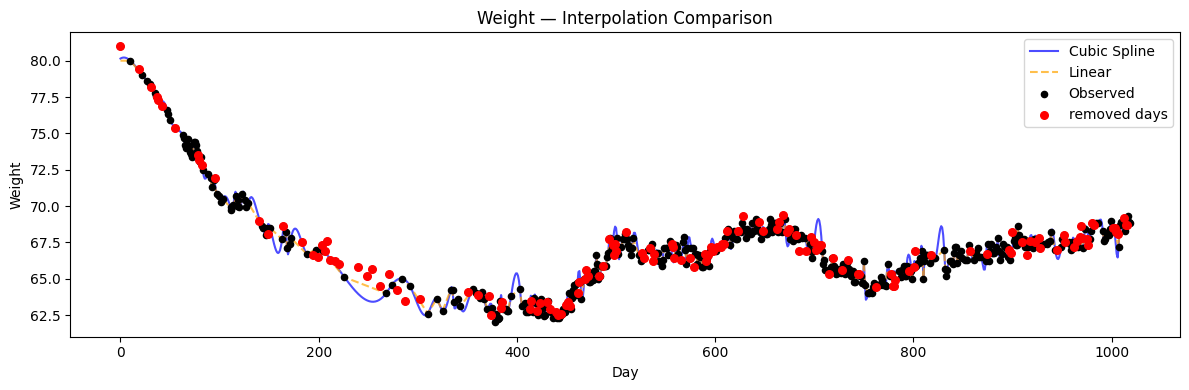


── Calories Interpolation ──
  Linear → MAE: 224.242,  RMSE: 292.961
  Spline → MAE: 273.524,  RMSE: 362.314


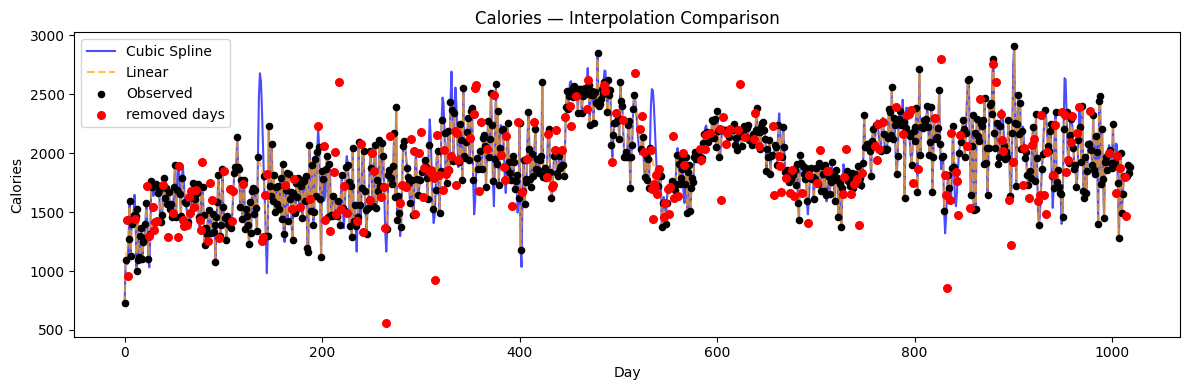

In [6]:
def interpolate_and_compare(df):
    results = {}

    for column in ["Weight", "Calories"]:
        known = df[df[column].notna()].copy()
        days = known["day"].values
        values = known[column].values

        # remove 25% for error comparison
        np.random.seed(42)
        test_idx = np.sort(np.random.choice(len(days), size=len(days)//4, replace=False))
        train_days = np.delete(days, test_idx)
        train_values = np.delete(values, test_idx)
        test_days = days[test_idx]
        true_values = values[test_idx]

        # Linear
        linear_pred = np.interp(test_days, train_days, train_values)

        # Cubic spline
        cs = CubicSpline(train_days, train_values)
        spline_pred = cs(test_days)

        # Errors
        linear_mae  = np.mean(np.abs(linear_pred - true_values))
        spline_mae  = np.mean(np.abs(spline_pred - true_values))
        linear_rmse = np.sqrt(np.mean((linear_pred - true_values) ** 2))
        spline_rmse = np.sqrt(np.mean((spline_pred - true_values) ** 2))

        print(f"\n── {column} Interpolation ──")
        print(f"  Linear → MAE: {linear_mae:.3f},  RMSE: {linear_rmse:.3f}")
        print(f"  Spline → MAE: {spline_mae:.3f},  RMSE: {spline_rmse:.3f}")

        # Fill all days using both methods
        all_days = df["day"].values
        df[f"{column}_linear"] = np.interp(all_days, train_days, train_values)
        df[f"{column}_spline"] = cs(all_days)

        results[column] = {
            "linear_mae": linear_mae, "spline_mae": spline_mae,
            "linear_rmse": linear_rmse, "spline_rmse": spline_rmse,
            "spline_fn": cs
        }

        # Plot
        plt.figure(figsize=(12, 4))
        plt.plot(all_days, df[f"{column}_spline"], label="Cubic Spline", color="blue", alpha=0.7)
        plt.plot(all_days, df[f"{column}_linear"], label="Linear",       color="orange", alpha=0.7, linestyle="--")
        plt.scatter(days, values, label="Observed", color="black", zorder=5, s=20)
        plt.scatter(test_days, true_values, label="removed days", color="red", zorder=6, s=30)
        plt.xlabel("Day")
        plt.ylabel(column)
        plt.title(f"{column} — Interpolation Comparison")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return df, results

df1 = pd.read_csv("output.csv")
df2, results = interpolate_and_compare(df1)
df2.to_csv("spline.csv", index = False)

Since MAE and RMSE for linear are lower, we can find a polynomial fit for the data to detect cutting and bulking phases.

In [51]:
#Helper functions

def differentiate(f, x, h=0.01):
    """5-point stencil"""
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h)) / (12*h)

def best_degree(xs, ys, max_degree=15):
    """polynomial degree selection"""
    n = len(ys)
    best_deg = 1
    best_bic = np.inf

    for deg in range(1, max_degree + 1):
        coeffs = np.polyfit(xs, ys, deg)
        f = np.poly1d(coeffs)
        residuals = ys - f(xs)
        sse = np.sum(residuals ** 2)
        bic = n * np.log(sse / n) + deg * np.log(n)

        if bic < best_bic:
            best_bic = bic
            best_deg = deg

    return best_deg


Phase transitions:
  2023-09-23  bulk > cut
  2024-09-12  cut > bulk
  2025-05-29  bulk > cut
  2025-10-29  cut > bulk


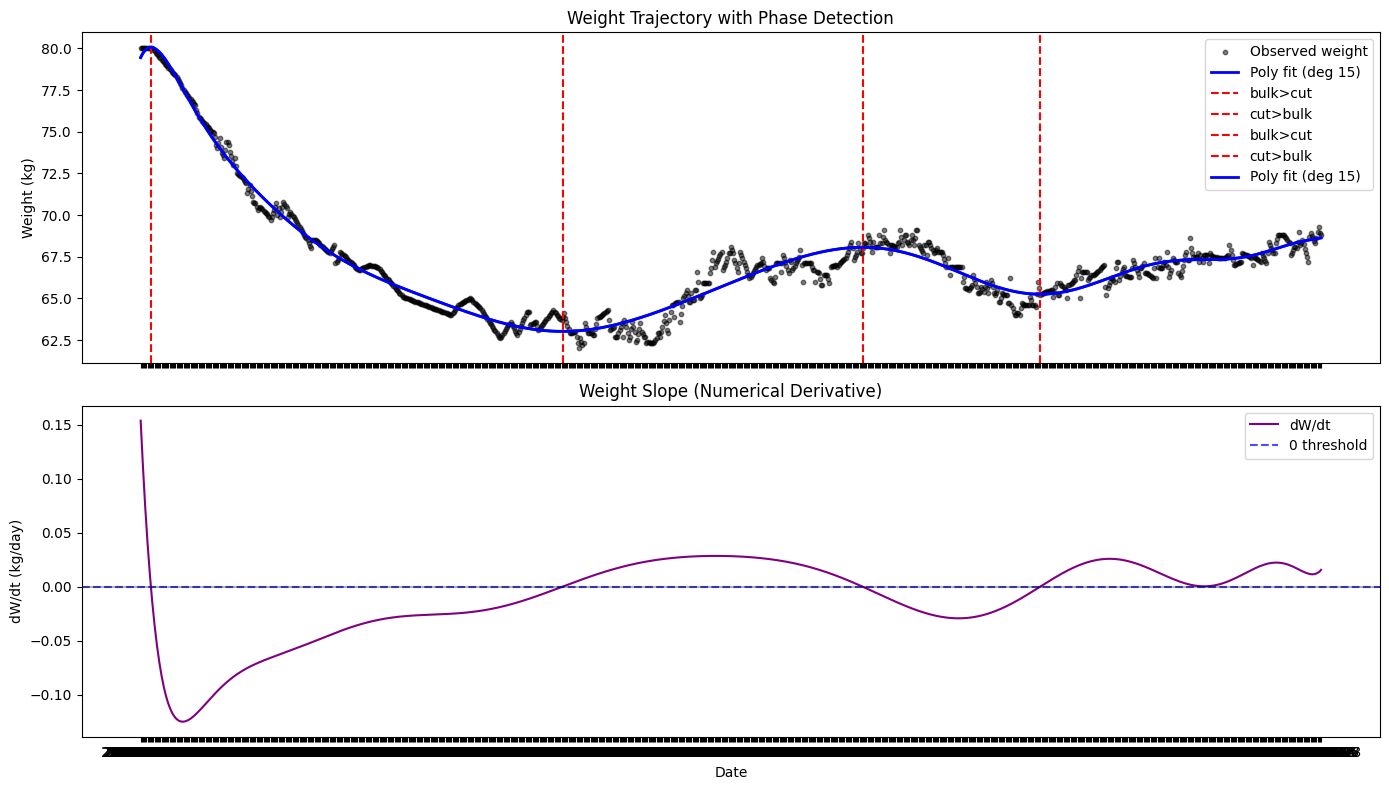

In [53]:
def detect_phases(df, slope_threshold=0):
    days = df["day"].values.astype(float)
    weight = df["Weight_linear"].values

    # Fit best polynomial to weight
    degree = best_degree(days, weight)
    coeffs = np.polyfit(days, weight, degree)
    f = np.poly1d(coeffs)

    # derivative at each day
    x = np.linspace(days.min(), days.max(), len(days))
    d = differentiate(f, x)

    # Classify each day
    phases = []
    for slope in d:
        if slope > slope_threshold:
            phases.append("bulk")
        elif slope < -slope_threshold:
            phases.append("cut")
        else:
            phases.append("maintenance")

    df["phase"] = phases
    df["fitted_weight"] = f(x)
    df["weight_slope"] = d

    # Find transition points (where phase changes)
    transitions = []
    for i in range(1, len(phases)):
        if phases[i] != phases[i-1]:
            transitions.append((df["Date"].iloc[i], phases[i-1], phases[i]))

    print("\nPhase transitions:")
    for date, prev, curr in transitions:
        print(f"  {date}  {prev} > {curr}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Weight + fitted curve
    ax1.scatter(df["Date"], df["Weight_linear"], color="black", s=10, alpha=0.5, label="Observed weight")
    ax1.plot(df["Date"], df["fitted_weight"], color="blue", linewidth=2, label=f"Poly fit (deg {degree})")

    # Vertical lines at transition points
    for date, prev, curr in transitions:
        ax1.axvline(x=date, color="red", linestyle="--", linewidth=1.5, label=f"{prev}>{curr}")

    ax1.set_ylabel("Weight (kg)")
    ax1.set_title("Weight Trajectory with Phase Detection")
    ax1.legend()
    ax1.plot(df["Date"], df["fitted_weight"], color="blue", linewidth=2, label=f"Poly fit (deg {degree})")
    ax1.set_ylabel("Weight (kg)")
    ax1.set_title("Weight Trajectory with Phase Detection")
    ax1.legend()

    # Derivative plot
    ax2.plot(df["Date"], d, color="purple", linewidth=1.5, label="dW/dt")
    ax2.axhline(y= slope_threshold, color="blue", linestyle="--", alpha=0.7, label=f"{slope_threshold} threshold")
    ax2.axhline(y=0, color="black", linestyle="-", alpha=0.3)
    ax2.set_ylabel("dW/dt (kg/day)")
    ax2.set_xlabel("Date")
    ax2.set_title("Weight Slope (Numerical Derivative)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df, transitions

df1 = pd.read_csv("spline.csv")
df2, transitions = detect_phases(df1)
df2.to_csv("segmented.csv", index = False)

Apply piece-wise regression by segmenting each weight change phase.


Phase transitions:
  2023-09-23  bulk > cut
  2024-09-12  cut > bulk
  2025-05-29  bulk > cut
  2025-10-29  cut > bulk


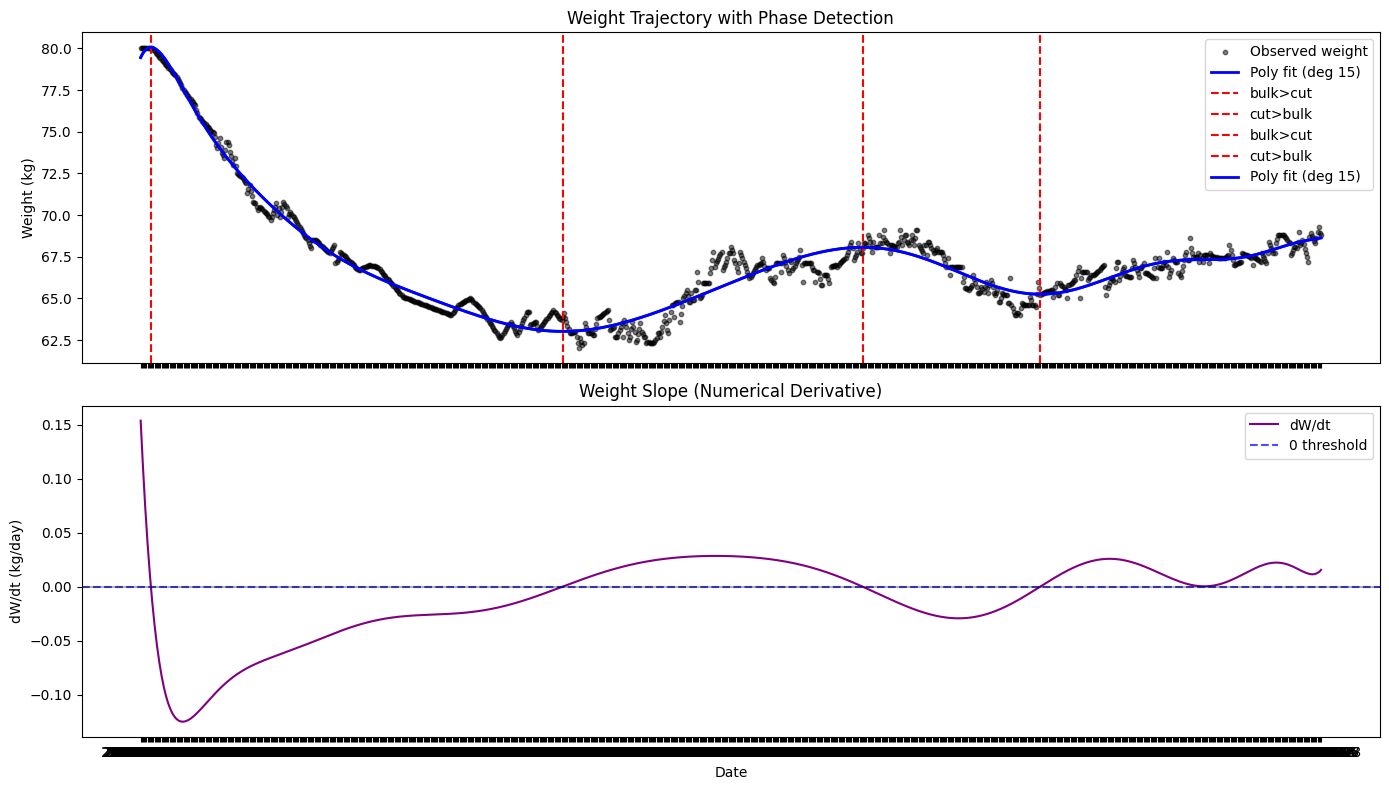

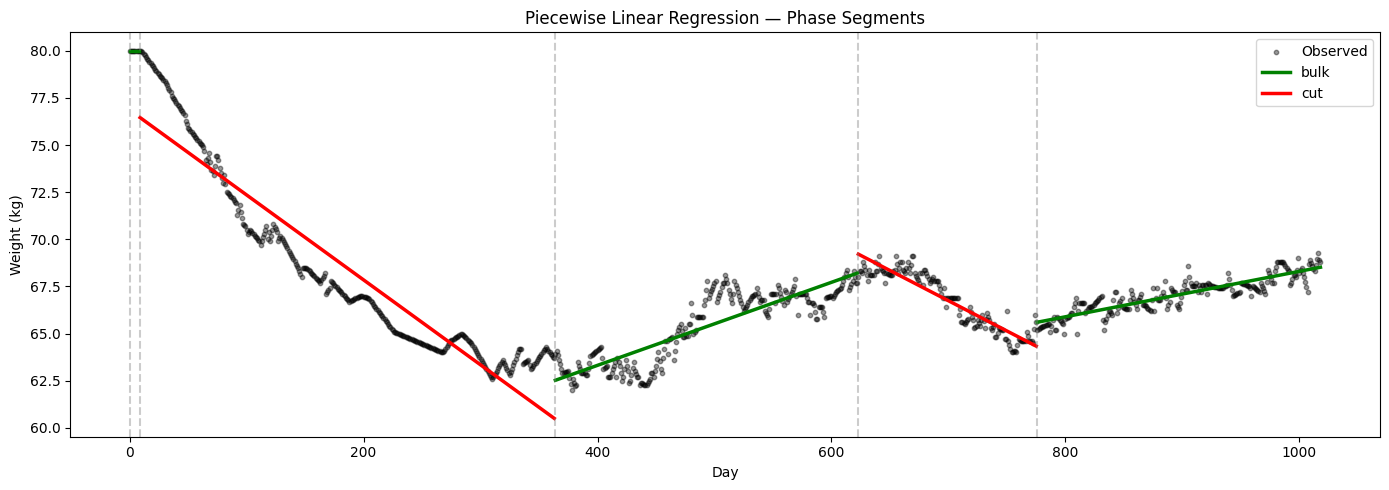

Phase  Start        End          Days        Slope   Avg Intake       TDEE
bulk   2023-09-14   2023-09-22   9         -0.0000         1222       1222
cut    2023-09-23   2024-09-11   355       -0.0450         1690       2037
bulk   2024-09-12   2025-05-28   259        0.0220         2069       1899
cut    2025-05-29   2025-10-28   153       -0.0321         1940       2187
bulk   2025-10-29   2026-06-28   243        0.0120         2038       1945


In [54]:
def piecewise(df, degree=4, slope_theshold = 0):
    days = df["day"].values.astype(float)
    weight = df["Weight_linear"].values
    cals = df["Calories_linear"].values
    phases = df["phase"].values
    segments = []
    start_idx = 0

    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start_idx]:
            end_idx = i
            
            seg_days = days[start_idx:end_idx]
            seg_weight = weight[start_idx:end_idx]
            seg_cals = cals[start_idx:end_idx]
            phase = phases[start_idx]

            if len(seg_days) >= 2:
                X = np.column_stack([np.ones_like(seg_days), seg_days])
                beta = np.linalg.solve(X.T @ X, X.T @ seg_weight)
                intercept, slope = beta[0], beta[1]
                avg_intake = np.mean(seg_cals)
                tdee_estimate = avg_intake - (slope * 7700)

                segments.append({
                    "start": seg_days[0],
                    "end": seg_days[-1],
                    "start_date": df["Date"].iloc[start_idx],
                    "end_date": df["Date"].iloc[end_idx - 1],
                    "phase": phase,
                    "slope": slope,
                    "intercept": intercept,
                    "avg_intake": avg_intake,
                    "tdee_estimate": tdee_estimate,
                    "n": len(seg_days),
                    "days": seg_days,
                    "weight": weight,
                })

            start_idx = i
    return segments
    
def plot_piecewise(df, segments):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = {"bulk": "green", "cut": "red", "maintenance": "gray"}

    ax.scatter(df["day"], df["Weight_linear"], color="black", s=10, alpha=0.4, label="Observed")

    seen_labels = set()
    for seg in segments:
        fitted = seg["intercept"] + seg["slope"] * seg["days"]
        label  = seg["phase"] if seg["phase"] not in seen_labels else None
        seen_labels.add(seg["phase"])

        ax.plot(seg["days"], fitted, color=colors[seg["phase"]], linewidth=2.5, label=label)
        ax.axvline(seg["start"], color="gray", linestyle="--", alpha=0.4)

    ax.set_xlabel("Day")
    ax.set_ylabel("Weight (kg)")
    ax.set_title("Piecewise Linear Regression — Phase Segments")
    ax.legend()
    plt.tight_layout()
    plt.show()

def print_segment_summary(segments):
    print(f"{'Phase':<6} {'Start':<12} {'End':<12} {'Days':<6} {'Slope':>10} {'Avg Intake':>12} {'TDEE':>10}")
    for s in segments:
        print(f"{s['phase']:<6} {s['start_date']:<12} {s['end_date']:<12} "
              f"{s['n']:<6} {s['slope']:>10.4f} {s['avg_intake']:>12.0f} {s['tdee_estimate']:>10.0f}")
        

df1 = pd.read_csv("spline.csv")
df2, transitions = detect_phases(df1)
segments = piecewise(df2)
plot_piecewise(df2, segments)
print_segment_summary(segments)